In [2]:
from Bio import SeqIO
import subprocess
import re
from concurrent.futures import ProcessPoolExecutor

def get_mfes(sequence):
    print(sequence[:5])
    # ensure newline for RNAfold
    seq_input = sequence.rstrip() + "\n"
    # run RNAfold safely
    try:
        proc1 = subprocess.run(
            ['/mnt/mr01-home01/m65338lb/.local/bin/micromamba', 'run', '-n', 'inseq', 'RNAfold', '--maxBPspan=200'],
            input=seq_input, text=True, capture_output=True, check=True
        )
    except subprocess.CalledProcessError:
        return None, None

    lines1 = proc1.stdout.strip().split('\n')
    mfe = None
    if len(lines1) >= 2:
        m1 = re.search(r'([().]+)\s*\(?([-+]?\d*\.\d+|\d+)\)?', lines1[1])
        mfe = float(m1.group(2)) if m1 else None
        print(f"RNAfold MFE: {mfe}")

    # run LinearFold safely
    if mfe:
        try:
            proc2 = subprocess.run(
                ['/mnt/mr01-home01/m65338lb/.local/bin/micromamba', 'run', '-n', 'inseq', 'linearfold', '-b', '200'],
                input=seq_input, text=True, capture_output=True, check=True
            )
        except subprocess.CalledProcessError:
            return None, None

        lines2 = proc2.stdout.strip().split('\n')
        mfe2 = None
        if len(lines2) >= 2:
            m2 = re.search(r'([().]+)\s*\(?([-+]?\d*\.\d+|\d+)\)?', lines2[1])
            mfe2 = float(m2.group(2)) if m2 else None
            print(f"LinearFold MFE: {mfe2}")
    else:
        return None, None

    return mfe, mfe2

# prepare input sequences
path = "/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/data/full_transcripts/Dmela-full_transcripts.fa"
seqs = (
    str(rec.seq).upper().replace('T', 'U')
    for rec in SeqIO.parse(path, 'fasta')
    if len(rec.seq) < 10_000
)

rnafold = []
linearfold = []
for s in seqs:
    mfe, mfe2 = get_mfes(s)
    if mfe is not None and mfe2 is not None:
        rnafold.append(mfe)
        linearfold.append(mfe2)
# with ProcessPoolExecutor() as executor:
#     for mfe, mfe2 in executor.map(get_mfes, seqs):
#         if mfe is not None and mfe2 is not None:
#             rnafold.append(mfe)
#             linearfold.append(mfe2)

print(f"Processed {len(rnafold)} sequences in parallel")

AUGUC
RNAfold MFE: -349.2
LinearFold MFE: 68.82
CAACA
RNAfold MFE: -1043.0
LinearFold MFE: 177.27
GCGCU
RNAfold MFE: -541.4
LinearFold MFE: 138.34
CUAGC
RNAfold MFE: -324.5
LinearFold MFE: 71.4
ACAAG
RNAfold MFE: -339.3
LinearFold MFE: 89.6
CUAAA
RNAfold MFE: -473.9
LinearFold MFE: 112.82
UUUUA
RNAfold MFE: -516.9
LinearFold MFE: 97.87
ACAGA
RNAfold MFE: -192.9
LinearFold MFE: 37.08
ACGAU
RNAfold MFE: -1787.5
LinearFold MFE: 343.62
GCCAG
RNAfold MFE: -1360.5
LinearFold MFE: 271.07
UGGUU
RNAfold MFE: -631.3
LinearFold MFE: 137.09
UCAGU
RNAfold MFE: -389.4
LinearFold MFE: 82.21
CGUGU
RNAfold MFE: -408.1
LinearFold MFE: 97.58
CAGUC
RNAfold MFE: -1634.3
LinearFold MFE: 283.4
CACAC
RNAfold MFE: -435.5
LinearFold MFE: 95.34
UCGAU
RNAfold MFE: -780.6
LinearFold MFE: 176.1
UCAGU
RNAfold MFE: -141.4
LinearFold MFE: 14.49
UUGGG
RNAfold MFE: -531.5
LinearFold MFE: 120.04
GCAGU
RNAfold MFE: -912.1
LinearFold MFE: 211.37
CGGCC
RNAfold MFE: -546.7
LinearFold MFE: 127.96
AUUUG
RNAfold MFE: -210.7
Lin

KeyboardInterrupt: 

In [4]:
import pickle

# Save rnafold and linearfold to a file
with open('/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/notebooks/explorativeJupyterNotebooks/rnafold_linearfold.pkl', 'wb') as f:
    pickle.dump({'rnafold': rnafold, 'linearfold': linearfold}, f)

In [9]:
path = "/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/translationEfficiency/output/data/full_transcripts/Dmela-full_transcripts.fa"
seqs = (
    str(rec.seq).upper().replace('T', 'U')
    for rec in SeqIO.parse(path, 'fasta')
    if len(rec.seq) < 10_000
)
len([s for s in seqs])

6899

Pearson r = -0.961 (p = 2.43e-37)
Spearman ρ = -0.970 (p = 7.25e-41)


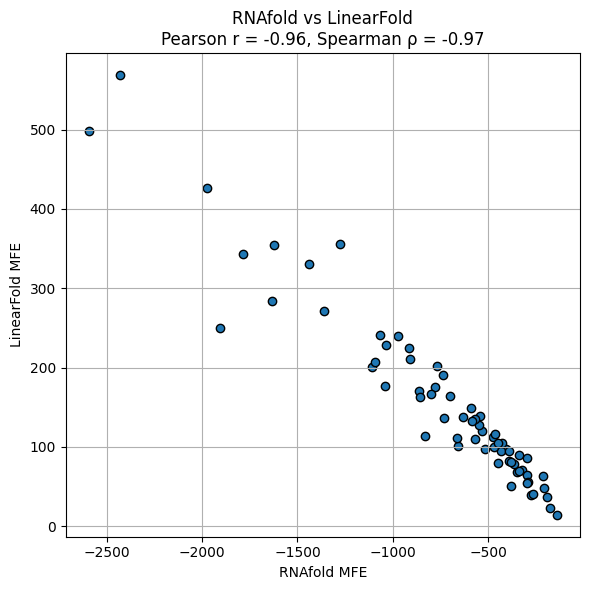

In [3]:
from scipy.stats import pearsonr, spearmanr

import matplotlib.pyplot as plt

# compute correlations
pearson_r, pearson_p = pearsonr(rnafold, linearfold)
spearman_rho, spearman_p = spearmanr(rnafold, linearfold)

print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.3g})")
print(f"Spearman ρ = {spearman_rho:.3f} (p = {spearman_p:.3g})")

# scatter plot
plt.figure(figsize=(6,6))
plt.scatter(rnafold, linearfold, edgecolor='k')
plt.xlabel("RNAfold MFE")
plt.ylabel("LinearFold MFE")
plt.title(f"RNAfold vs LinearFold\nPearson r = {pearson_r:.2f}, Spearman ρ = {spearman_rho:.2f}")
plt.grid(True)
plt.tight_layout()
plt.show()